# Ablation Study For Superposition Activations

This notebook turns the classifier into a paper-style benchmark. It keeps the dataset fixed to **Wine**, varies only one factor at a time, and reports mean and standard deviation across three model seeds.

In [ ]:
import sys
from pathlib import Path

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

import numpy as np
import matplotlib.pyplot as plt

from qfun.datasets import load_classification_dataset, prepare_classification_split
from qfun.qfan._classification_benchmarks import (
    plot_final_activation_profiles,
    plot_measurement_overlays,
    print_comparison_table,
    print_split_summary,
    run_quantum_experiment,
)


def aggregate_seed_metrics(label, results):
    accuracies = np.asarray([res.test_accuracy for res in results], dtype=float)
    macro_f1s = np.asarray([res.macro_f1 for res in results], dtype=float)
    return (
        label,
        float(np.mean(accuracies)),
        float(np.std(accuracies)),
        float(np.mean(macro_f1s)),
        float(np.std(macro_f1s)),
    )


def print_seed_aggregate_table(rows):
    headers = ("Setting", "Acc mean", "Acc std", "F1 mean", "F1 std")
    widths = [
        max(len(headers[0]), max(len(row[0]) for row in rows)),
        len(headers[1]),
        len(headers[2]),
        len(headers[3]),
        len(headers[4]),
    ]
    print(
        f"{headers[0]:<{widths[0]}} | {headers[1]:>{widths[1]}} | {headers[2]:>{widths[2]}} | {headers[3]:>{widths[3]}} | {headers[4]:>{widths[4]}}"
    )
    print(
        f"{'-' * widths[0]}-+-{'-' * widths[1]}-+-{'-' * widths[2]}-+-{'-' * widths[3]}-+-{'-' * widths[4]}"
    )
    for label, acc_mean, acc_std, f1_mean, f1_std in rows:
        print(
            f"{label:<{widths[0]}} | {acc_mean:>{widths[1]}.4f} | {acc_std:>{widths[2]}.4f} | {f1_mean:>{widths[3]}.4f} | {f1_std:>{widths[4]}.4f}"
        )


def run_seed_group(*, mode, split, hidden_units, n_qubits, steps, learning_rate, seeds, label_prefix, eval_shots=500):
    results = []
    for seed in seeds:
        results.append(
            run_quantum_experiment(
                mode,
                label=f"{label_prefix} (seed={seed})",
                split=split,
                hidden_units=hidden_units,
                n_qubits=n_qubits,
                steps=steps,
                learning_rate=learning_rate,
                seed=seed,
                log_every=None,
                snapshot_interval=5,
                eval_shots=eval_shots,
            )
        )
    return results


def plot_metric_curve(x_values, mean_values, std_values, *, xlabel, ylabel, title):
    plt.figure(figsize=(6, 3.5))
    plt.errorbar(x_values, mean_values, yerr=std_values, marker="o", capsize=4)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(0.0, 1.02)
    plt.show()

## Config

The dataset split stays fixed, while the ablations average over three model seeds `[7, 13, 21]`.

In [2]:
dataset_name = "wine"
data_seed = 7
model_seeds = [7, 13, 21]
test_size = 0.25

hidden_units = 4
n_qubits = 3
steps = 30
learning_rate = 0.05
measurement_shots = [500, 2_000, 10_000]

## 1. Load And Prepare The Fixed Dataset

All ablations below use the same Wine train/test split. Only the model settings change.

In [3]:
dataset = load_classification_dataset(dataset_name)
split = prepare_classification_split(
    dataset,
    test_size=test_size,
    seed=data_seed,
    standardize=True,
)
print_split_summary(dataset.name, split)

Dataset: Wine
Classes: ['class_0', 'class_1', 'class_2']
Training set: 133 samples
Test set:     45 samples
Feature dimension: 13
Train class counts: [44 53 36]
Test class counts:  [15 18 12]


## 2. Mode Comparison

This block compares `standard`, `mode_a`, and `mode_b` under the same base configuration, aggregated across three model seeds.

In [4]:
mode_groups = {
    "Standard": run_seed_group(
        mode="standard",
        split=split,
        hidden_units=hidden_units,
        n_qubits=n_qubits,
        steps=steps,
        learning_rate=learning_rate,
        seeds=model_seeds,
        label_prefix="Standard",
    ),
    "Mode A": run_seed_group(
        mode="mode_a",
        split=split,
        hidden_units=hidden_units,
        n_qubits=n_qubits,
        steps=steps,
        learning_rate=learning_rate,
        seeds=model_seeds,
        label_prefix="Mode A",
    ),
    "Mode B": run_seed_group(
        mode="mode_b",
        split=split,
        hidden_units=hidden_units,
        n_qubits=n_qubits,
        steps=steps,
        learning_rate=learning_rate,
        seeds=model_seeds,
        label_prefix="Mode B",
    ),
}

mode_rows = [aggregate_seed_metrics(label, results) for label, results in mode_groups.items()]
print_seed_aggregate_table(mode_rows)

Setting  | Acc mean | Acc std | F1 mean | F1 std
---------+----------+---------+---------+-------
Standard |   0.9111 |  0.0181 |  0.9083 | 0.0202
Mode A   |   0.9556 |  0.0000 |  0.9554 | 0.0015
Mode B   |   0.9481 |  0.0105 |  0.9486 | 0.0101


## 3. Qubit Sweep

Here we keep the mode fixed to `standard` and vary `n_qubits` through `[2, 3, 4]`.

Setting    | Acc mean | Acc std | F1 mean | F1 std
-----------+----------+---------+---------+-------
n_qubits=2 |   0.9481 |  0.0277 |  0.9486 | 0.0282
n_qubits=3 |   0.9111 |  0.0181 |  0.9083 | 0.0202
n_qubits=4 |   0.9556 |  0.0314 |  0.9580 | 0.0303


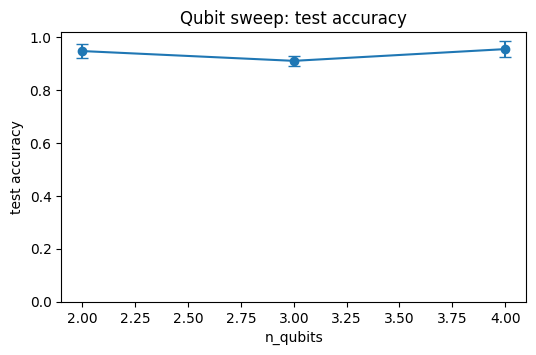

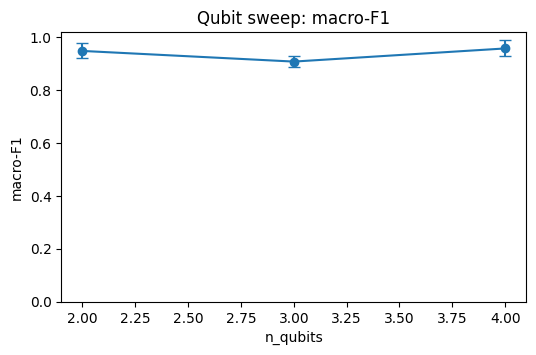

In [5]:
qubit_values = [2, 3, 4]
qubit_groups = {}
for q in qubit_values:
    qubit_groups[q] = run_seed_group(
        mode="standard",
        split=split,
        hidden_units=hidden_units,
        n_qubits=q,
        steps=steps,
        learning_rate=learning_rate,
        seeds=model_seeds,
        label_prefix=f"standard, n_qubits={q}",
    )

qubit_rows = [aggregate_seed_metrics(f"n_qubits={q}", qubit_groups[q]) for q in qubit_values]
print_seed_aggregate_table(qubit_rows)

plot_metric_curve(
    qubit_values,
    [row[1] for row in qubit_rows],
    [row[2] for row in qubit_rows],
    xlabel="n_qubits",
    ylabel="test accuracy",
    title="Qubit sweep: test accuracy",
)
plot_metric_curve(
    qubit_values,
    [row[3] for row in qubit_rows],
    [row[4] for row in qubit_rows],
    xlabel="n_qubits",
    ylabel="macro-F1",
    title="Qubit sweep: macro-F1",
)

## 4. Hidden-Unit Sweep

This block keeps the mode fixed to `standard` and varies the number of hidden units.

Setting        | Acc mean | Acc std | F1 mean | F1 std
---------------+----------+---------+---------+-------
hidden_units=3 |   0.9111 |  0.0480 |  0.9073 | 0.0539
hidden_units=4 |   0.9111 |  0.0181 |  0.9083 | 0.0202
hidden_units=6 |   0.9630 |  0.0378 |  0.9641 | 0.0358
hidden_units=8 |   0.9556 |  0.0181 |  0.9561 | 0.0182


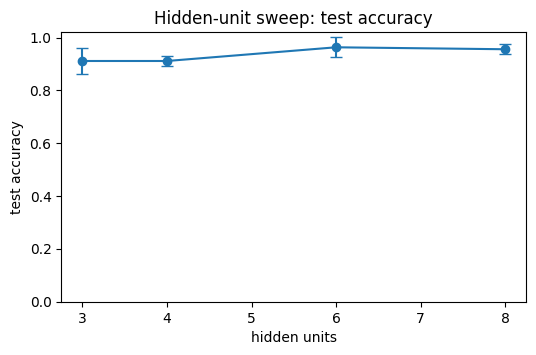

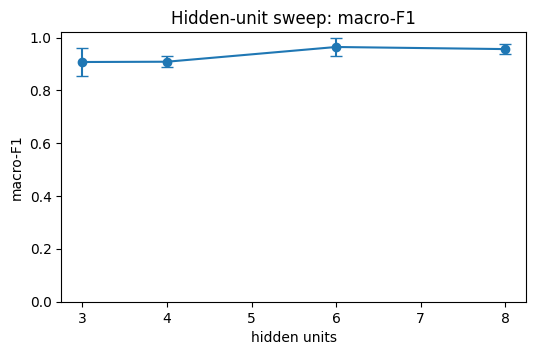

In [6]:
hidden_unit_values = [3, 4, 6, 8]
hidden_unit_groups = {}
for width in hidden_unit_values:
    hidden_unit_groups[width] = run_seed_group(
        mode="standard",
        split=split,
        hidden_units=width,
        n_qubits=n_qubits,
        steps=steps,
        learning_rate=learning_rate,
        seeds=model_seeds,
        label_prefix=f"standard, hidden_units={width}",
    )

hidden_unit_rows = [
    aggregate_seed_metrics(f"hidden_units={width}", hidden_unit_groups[width])
    for width in hidden_unit_values
]
print_seed_aggregate_table(hidden_unit_rows)

plot_metric_curve(
    hidden_unit_values,
    [row[1] for row in hidden_unit_rows],
    [row[2] for row in hidden_unit_rows],
    xlabel="hidden units",
    ylabel="test accuracy",
    title="Hidden-unit sweep: test accuracy",
)
plot_metric_curve(
    hidden_unit_values,
    [row[3] for row in hidden_unit_rows],
    [row[4] for row in hidden_unit_rows],
    xlabel="hidden units",
    ylabel="macro-F1",
    title="Hidden-unit sweep: macro-F1",
)

## 5. Measurement Sensitivity

Finally, we train one base `standard` model and measure the same learned activation profiles at three shot counts to see how the reconstruction error changes.

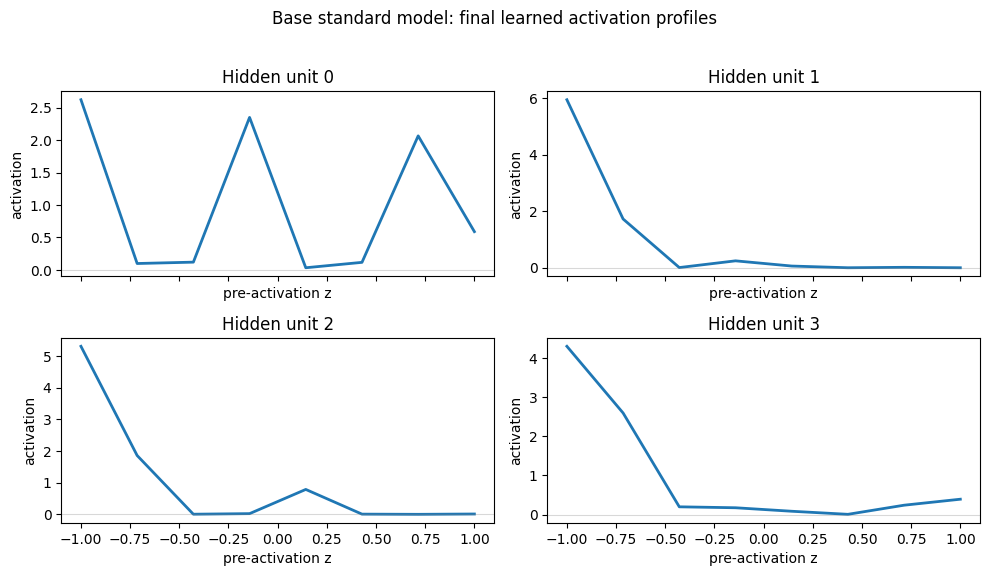

unit 0: exact-vs-measured L1 = 0.566838
unit 2: exact-vs-measured L1 = 0.278830


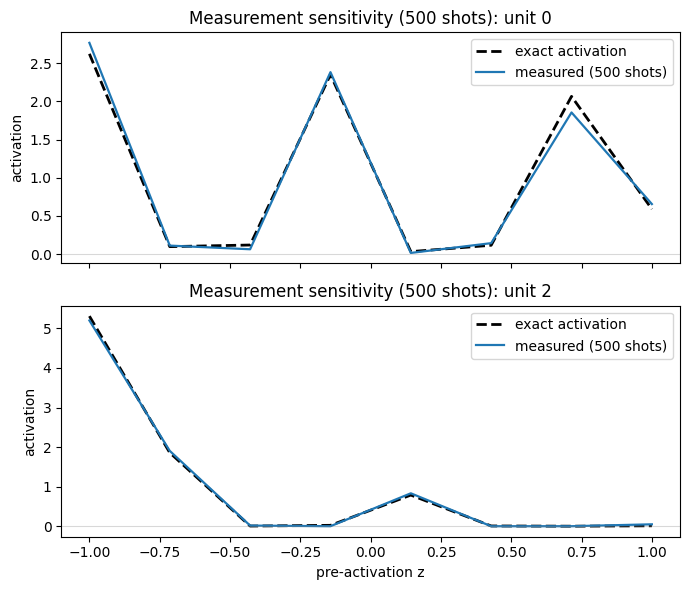

unit 0: exact-vs-measured L1 = 0.127271
unit 2: exact-vs-measured L1 = 0.194315


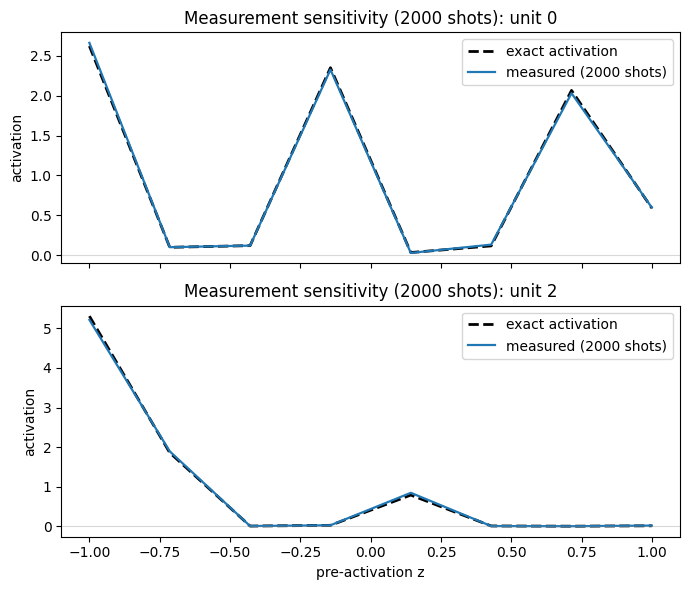

unit 0: exact-vs-measured L1 = 0.071453
unit 2: exact-vs-measured L1 = 0.136979


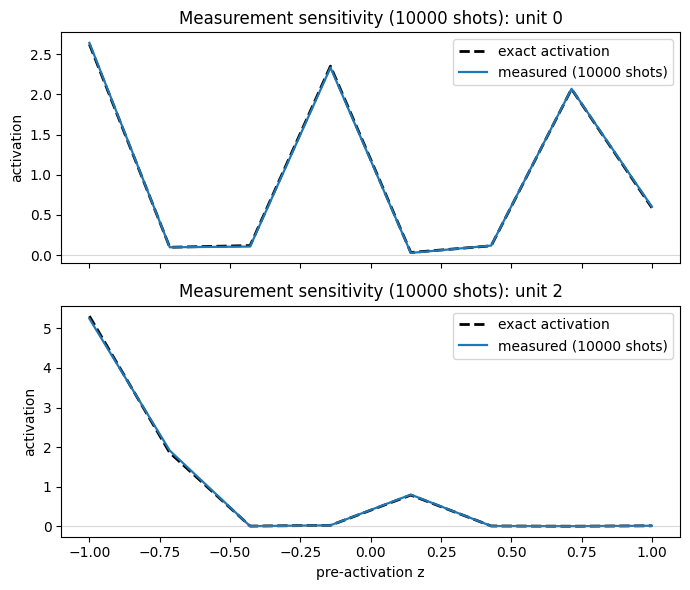

Shots | mean L1 | std L1
  500 | 0.422834 | 0.144004
 2000 | 0.160793 | 0.033522
10000 | 0.104216 | 0.032763


In [7]:
base_result = run_quantum_experiment(
    "standard",
    label="Standard base model",
    split=split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=model_seeds[0],
    log_every=None,
    snapshot_interval=5,
    eval_shots=measurement_shots[0],
)
plot_final_activation_profiles(
    base_result.model,
    title="Base standard model: final learned activation profiles",
)

measurement_rows = []
for shots in measurement_shots:
    measurements = tuple(
        base_result.model.measure_activation_profile(unit_idx, shots=shots)
        for unit_idx in base_result.representative_units
    )
    l1_errors = [
        float(np.sum(np.abs(base_result.model.get_activation_profile(unit_idx) - measurement.profile)))
        for unit_idx, measurement in zip(base_result.representative_units, measurements)
    ]
    measurement_rows.append((shots, float(np.mean(l1_errors)), float(np.std(l1_errors))))
    plot_measurement_overlays(
        base_result.model,
        base_result.representative_units,
        measurements,
        shots=shots,
        title_prefix=f"Measurement sensitivity ({shots} shots)",
    )

print("Shots | mean L1 | std L1")
for shots, mean_l1, std_l1 in measurement_rows:
    print(f"{shots:5d} | {mean_l1:.6f} | {std_l1:.6f}")